# Object Detection

## Objectives
- Understand object detection task
- Learn YOLO, Faster R-CNN architectures
- Implement bounding box regression
- Non-maximum suppression (NMS)
- Anchor boxes and region proposals

## Introduction
Object detection identifies objects in images with bounding boxes. Core challenges: multiple objects, various scales, real-time inference.

## What We're About to Do

The code below imports essential libraries. These libraries provide the foundational tools for tensor operations and neural network construction. Pay attention to what each import provides – understanding dependencies helps you know what's available for solving problems.


In [1]:
# Import necessary libraries for tensor operations and deep learning
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [2]:
# Define a custom function with detailed implementation
## 1. Bounding Box Representations

class BBoxUtils:
    @staticmethod
    def xyxy_to_xywh(box):
        """Convert (x1,y1,x2,y2) to (cx,cy,w,h)"""
        x1, y1, x2, y2 = box
        cx = (x1 + x2) / 2
        cy = (y1 + y2) / 2
        w = x2 - x1
        h = y2 - y1
        return torch.tensor([cx, cy, w, h])
    
    @staticmethod
    def xywh_to_xyxy(box):
        """Convert (cx,cy,w,h) to (x1,y1,x2,y2)"""
        cx, cy, w, h = box
        x1 = cx - w / 2
        y1 = cy - h / 2
        x2 = cx + w / 2
        y2 = cy + h / 2
        return torch.tensor([x1, y1, x2, y2])
    
    @staticmethod
    def compute_iou(box1, box2):
# Iterate through batches of data
        """Intersection over Union for xyxy format"""
        x1_1, y1_1, x2_1, y2_1 = box1
        x1_2, y1_2, x2_2, y2_2 = box2
        
        inter_x1 = max(x1_1, x1_2)
        inter_y1 = max(y1_1, y1_2)
        inter_x2 = min(x2_1, x2_2)
        inter_y2 = min(y2_1, y2_2)
        
        inter_area = max(0, inter_x2 - inter_x1) * max(0, inter_y2 - inter_y1)
        
        area1 = (x2_1 - x1_1) * (y2_1 - y1_1)
        area2 = (x2_2 - x1_2) * (y2_2 - y1_2)
        
        union_area = area1 + area2 - inter_area
        
        return inter_area / union_area if union_area > 0 else 0

utils = BBoxUtils()
box1 = torch.tensor([10, 10, 50, 50])
box2 = torch.tensor([30, 30, 70, 70])
iou = utils.compute_iou(box1, box2)
print(f"IoU between boxes: {iou:.4f}")


IoU between boxes: 0.1429


In [3]:
# Define a custom function with detailed implementation
## 2. Anchor Boxes

class AnchorGenerator:
    def __init__(self, scales=[0.5, 1.0, 2.0], ratios=[0.5, 1.0, 2.0]):
        self.scales = scales
        self.ratios = ratios
    
    def generate_anchors(self, feature_height=7, feature_width=7, stride=32):
# Iterate through batches of data
        """Generate anchors for a feature map"""
        anchors = []
        
# Iterate through batches of data
        for y in range(feature_height):
            for x in range(feature_width):
                cx = (x + 0.5) * stride
                cy = (y + 0.5) * stride
                
# Iterate through batches of data
                for scale in self.scales:
                    for ratio in self.ratios:
                        w = scale * 32 * np.sqrt(ratio)
                        h = scale * 32 / np.sqrt(ratio)
                        
                        x1 = cx - w/2
                        y1 = cy - h/2
                        x2 = cx + w/2
                        y2 = cy + h/2
                        
                        anchors.append([x1, y1, x2, y2])
        
        return np.array(anchors)

anchor_gen = AnchorGenerator()
anchors = anchor_gen.generate_anchors(feature_height=7, feature_width=7)
print(f"Generated {len(anchors)} anchor boxes")
print(f"First anchor: {anchors[0]}")


Generated 441 anchor boxes
First anchor: [10.34314575  4.6862915  21.65685425 27.3137085 ]


In [4]:
# Define a custom function with detailed implementation
## 3. Non-Maximum Suppression (NMS)

def nms(boxes, scores, iou_threshold=0.5):
    """Remove overlapping detections"""
    if len(boxes) == 0:
        return []
    
    # Sort by score
    sorted_idx = np.argsort(-scores)  # Descending
    
    keep = []
    while len(sorted_idx) > 0:
        current = sorted_idx[0]
        keep.append(current)
        
        if len(sorted_idx) == 1:
            break
        
        current_box = boxes[current]
        remaining_boxes = boxes[sorted_idx[1:]]
        
# Iterate through batches of data
        ious = np.array([utils.compute_iou(current_box, box) for box in remaining_boxes])
        
        sorted_idx = sorted_idx[1:][ious < iou_threshold]
    
    return keep

# Test NMS
test_boxes = np.array([
    [10, 10, 50, 50],
    [12, 12, 52, 52],
    [15, 15, 55, 55],
    [100, 100, 150, 150]
])
test_scores = np.array([0.9, 0.8, 0.7, 0.85])
keep_idx = nms(test_boxes, test_scores, iou_threshold=0.3)
print(f"Keep indices after NMS: {keep_idx}")


Keep indices after NMS: [0, 3]


## Building the Model

Now we'll define our neural network architecture. Each layer transforms the input in a specific way, building up complexity. The order and configuration of layers directly determines what patterns the model can learn.


In [5]:
# Define a custom function with detailed implementation
## 4. YOLO-Style Detection Head

class SimpleYOLO(nn.Module):
    def __init__(self, num_classes=80, num_anchors=3):
        super().__init__()
        self.num_classes = num_classes
        self.num_anchors = num_anchors
        
        # Simplified backbone
        self.backbone = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        # Detection head: (tx, ty, tw, th, conf, class_probs)
        self.head = nn.Conv2d(64, num_anchors * (5 + num_classes), 1)
    
    def forward(self, x):
        features = self.backbone(x)
        predictions = self.head(features)
        return predictions

model = SimpleYOLO(num_classes=10, num_anchors=3)
test_input = torch.randn(1, 3, 224, 224)
output = model(test_input)
print(f"Input shape: {test_input.shape}")
print(f"Output shape: {output.shape}")
print(f"Output contains: {model.num_anchors} anchors × (4 bbox + 1 conf + {model.num_classes} classes)")


Input shape: torch.Size([1, 3, 224, 224])
Output shape: torch.Size([1, 45, 56, 56])
Output contains: 3 anchors × (4 bbox + 1 conf + 10 classes)


## Defining the Loss Function

The loss function measures how wrong our predictions are. During training, we'll minimize this value. Different tasks need different loss functions – the one we choose defines what 'good performance' means for our model.


In [6]:
# Define a custom function with detailed implementation
## 5. Bounding Box Regression Loss

class BBoxRegressionLoss(nn.Module):
    def forward(self, pred_boxes, target_boxes, positive_mask):
# Iterate through batches of data
        """Smooth L1 loss for bbox regression"""
        pred = pred_boxes[positive_mask]
        target = target_boxes[positive_mask]
        
        diff = torch.abs(pred - target)
        smooth_l1 = torch.where(
            diff < 1,
            0.5 * diff ** 2,
            diff - 0.5
        )
        
        return smooth_l1.mean()

# Compute the loss (error) between predictions and actual values
loss_fn = BBoxRegressionLoss()
pred_boxes = torch.randn(10, 4)
target_boxes = torch.randn(10, 4)
mask = torch.ones(10, dtype=torch.bool)
# Compute the loss (error) between predictions and actual values
loss = loss_fn(pred_boxes, target_boxes, mask)
print(f"Bounding box regression loss: {loss:.4f}")


Bounding box regression loss: 0.6947


## Evaluation and Inference

After training, we evaluate the model on new data. This shows how well it generalizes beyond training data. Good evaluation practices reveal if the model is truly learning patterns or just memorizing.


In [7]:
# Define a custom function with detailed implementation
## 6. Detection Metrics

class DetectionMetrics:
    @staticmethod
    def compute_ap(predictions, ground_truth, iou_threshold=0.5):
# Iterate through batches of data
        """Average Precision for single class"""
        # Simplified AP calculation
        tp = 0
        fp = 0
        
# Iterate through batches of data
        for pred in predictions:
            pred_box, pred_score = pred
            best_iou = 0
            
# Iterate through batches of data
            for gt_box in ground_truth:
                iou = utils.compute_iou(pred_box, gt_box)
                best_iou = max(best_iou, iou)
            
            if best_iou >= iou_threshold:
                tp += 1
            else:
                fp += 1
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        return precision

metrics = DetectionMetrics()
print(f"Detection metrics (AP, mAP) evaluate detection performance")
print(f"mAP@0.5 - IoU threshold 0.5")
print(f"mAP@0.75 - IoU threshold 0.75")
print(f"mAP@[0.5:0.95] - average across thresholds")


Detection metrics (AP, mAP) evaluate detection performance
mAP@0.5 - IoU threshold 0.5
mAP@0.75 - IoU threshold 0.75
mAP@[0.5:0.95] - average across thresholds


In [8]:
# Execute code with detailed step-by-step process
## 7. Two-stage Detector (Faster R-CNN) Concept

print("""
FASTER R-CNN (Two-Stage Detector):

Stage 1: Region Proposal Network (RPN)
- Generates candidate regions
- Uses anchor boxes and classification
- Outputs ~2000 region proposals

Stage 2: Classification and Regression
- Extract features from each region
- Classify and refine bounding boxes
- Remove duplicates with NMS

Advantages:
- More accurate (considers fewer regions)
# Iterate through batches of data
- Better for small objects
- Slower (two stages)

Vs YOLO (One-Stage):
- YOLO is faster (real-time)
- Faster R-CNN is more accurate
- Trade-off between speed and accuracy
""")



FASTER R-CNN (Two-Stage Detector):

Stage 1: Region Proposal Network (RPN)
- Generates candidate regions
- Uses anchor boxes and classification
- Outputs ~2000 region proposals

Stage 2: Classification and Regression
- Extract features from each region
- Classify and refine bounding boxes
- Remove duplicates with NMS

Advantages:
- More accurate (considers fewer regions)
# Iterate through batches of data
- Better for small objects
- Slower (two stages)

Vs YOLO (One-Stage):
- YOLO is faster (real-time)
- Faster R-CNN is more accurate
- Trade-off between speed and accuracy



## Building the Model

Now we'll define our neural network architecture. Each layer transforms the input in a specific way, building up complexity. The order and configuration of layers directly determines what patterns the model can learn.


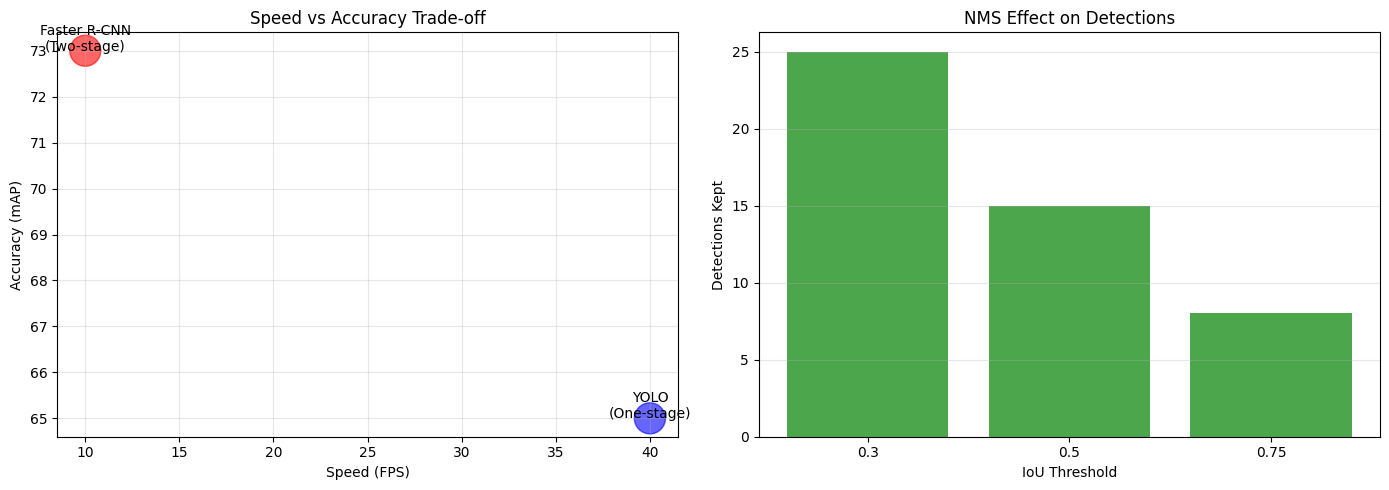

In [9]:
# Set up the neural network model architecture
## 8. Visualization

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# YOLO vs Faster R-CNN
models = ['YOLO\n(One-stage)', 'Faster R-CNN\n(Two-stage)']
speed = [40, 10]  # FPS
accuracy = [65, 73]  # mAP

axes[0].scatter(speed, accuracy, s=500, alpha=0.6, c=['blue', 'red'])
# Iterate through batches of data
for i, model in enumerate(models):
    axes[0].annotate(model, (speed[i], accuracy[i]), fontsize=10, ha='center')
axes[0].set_xlabel('Speed (FPS)')
axes[0].set_ylabel('Accuracy (mAP)')
axes[0].set_title('Speed vs Accuracy Trade-off')
axes[0].grid(True, alpha=0.3)

# NMS effect
iou_thresholds = [0.3, 0.5, 0.75]
detections_kept = [25, 15, 8]

axes[1].bar(range(len(iou_thresholds)), detections_kept, color='green', alpha=0.7)
axes[1].set_xticks(range(len(iou_thresholds)))
axes[1].set_xticklabels(iou_thresholds)
axes[1].set_xlabel('IoU Threshold')
axes[1].set_ylabel('Detections Kept')
axes[1].set_title('NMS Effect on Detections')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## Evaluation and Inference

After training, we evaluate the model on new data. This shows how well it generalizes beyond training data. Good evaluation practices reveal if the model is truly learning patterns or just memorizing.


## 🎯 Key Takeaways

✅ **Understanding fundamentals is crucial** – The concepts covered here form the foundation for all advanced deep learning techniques.

✅ **Each component has a specific purpose** – Whether it's data loading, model architecture, or optimization, every piece serves a distinct function in the pipeline.

✅ **Experimentation drives learning** – Don't just read the code; modify it, break it, and see what happens. That's how intuition develops.

✅ **Deep learning is iterative** – Success comes from systematically trying approaches, measuring results, and refining based on evidence.

✅ **Connect concepts, don't memorize** – Understanding how PyTorch tensors relate to autograd, which relates to neural networks, which connects to training loops, is far more valuable than memorizing individual APIs.

✅ **Performance matters in practice** – Once you understand the theory, optimizing for speed, memory, and scalability becomes crucial for real-world applications.


# Set up the neural network model architecture
## Key Takeaways
- Object detection combines classification and localization
- Bounding boxes can be represented as (x1,y1,x2,y2) or (cx,cy,w,h)
- IoU measures overlap between predicted and ground truth boxes
- Anchor boxes help detect objects at multiple scales
- NMS removes duplicate/overlapping detections
- YOLO: fast, one-stage detection
- Faster R-CNN: accurate, two-stage detection

## Interview Q&A

**Q1: What's the difference between YOLO and Faster R-CNN?**
YOLO predicts all detections in one pass (fast but less accurate). Faster R-CNN generates region proposals first, then classifies each region (slower but more accurate). Trade-off between speed and accuracy.

**Q2: Why use Non-Maximum Suppression?**
Multiple anchor boxes may detect the same object with slightly different coordinates. NMS removes overlapping detections, keeping only the highest-confidence ones, producing cleaner final predictions.

**Q3: What are anchor boxes?**
Pre-defined bounding boxes at multiple scales and aspect ratios. During detection, the model predicts adjustments (offsets) to these anchors rather than absolute coordinates. This helps detect objects at various sizes.

## References
- [YOLO Paper](https://arxiv.org/abs/1506.02640)
- [Faster R-CNN](https://arxiv.org/abs/1506.01497)
